# FlexBend Koopman identification (nonlinear decoder)

SISO educated-guess hyperparameters, no HPO. Train pch1–pch5, dev pch6, test pch7–pch9 resampled to $T_s=0.05$ s.


In [13]:
import os
# OpenMP/MKL + PyTorch on macOS segfaults the Jupyter kernel during backward
# unless thread counts are pinned before numpy/torch are imported.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

torch.set_num_threads(1)

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.insert(0, os.path.join(os.getcwd()))
sys.path.insert(0, os.path.join(project_root, "src"))
IDENT_DIR = Path.cwd()
DATA_DIR = IDENT_DIR.parent / "data"

import helper
from data_utils import NSTEPS, TS, load_flexy_splits, save_flexy_npz
from helper.koopman import (
    LossWeights,
    TrainConfig,
    build_koopman_problem,
    evaluate_mae_physical,
    extract_matrices,
    get_data_loaders,
    train_koopman,
)

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading a Dataset


Ts = 0.05 s, nsteps = 40, train 3800 / dev 760 / test 2280
train ids [1, 2, 3, 4, 5] ['40 -> 80', '50 -> 80', '20 -> 40', '30 -> 10', '70 -> 30']
dev ids   [6] ['40 -> 90']
test ids  [7, 8, 9] ['40 -> 80', '50 -> 80', '35 -> 55']


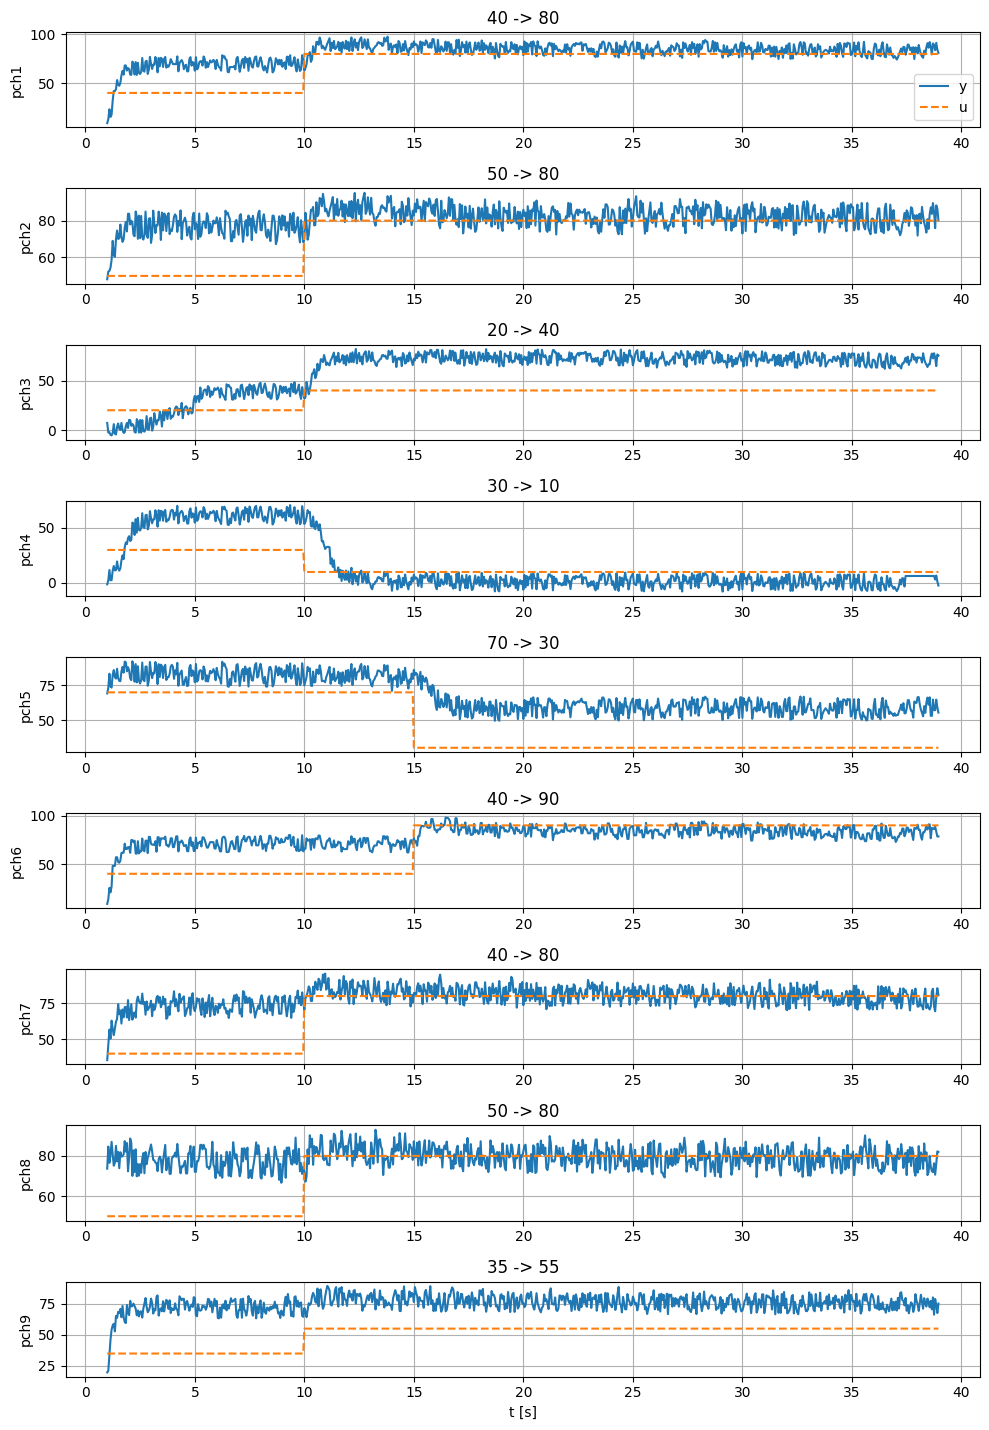

In [14]:
experiments, train_exps, dev_exps, test_exps, train, dev, test = load_flexy_splits()
save_flexy_npz()
y_names = ["y"]
print(
    f"Ts = {TS} s, nsteps = {NSTEPS}, "
    f"train {train['Y'].shape[0]} / dev {dev['Y'].shape[0]} / test {test['Y'].shape[0]}"
)
print("train ids", [e["id"] for e in train_exps], [e["label"] for e in train_exps])
print("dev ids  ", [e["id"] for e in dev_exps], [e["label"] for e in dev_exps])
print("test ids ", [e["id"] for e in test_exps], [e["label"] for e in test_exps])

n_plot = len(experiments)
fig, axs = plt.subplots(n_plot, 1, figsize=(10, 1.6 * n_plot), sharex=False)
for ax, exp in zip(axs, experiments.values()):
    ax.plot(exp["t"], exp["Y"][:, 0], label="y")
    ax.plot(exp["t"], exp["U"][:, 0], "--", label="u")
    ax.set_ylabel(f"pch{exp['id']}")
    ax.set_title(exp["label"])
    ax.grid(True)
axs[0].legend(loc="best")
axs[-1].set_xlabel("t [s]")
fig.tight_layout()


## Preparing data


In [15]:
nsteps = 40  # HPO winner
bs = 16
scaler = StandardScaler().fit(train["Y"])
scalerU = StandardScaler().fit(train["U"])
joblib.dump(scaler, DATA_DIR / "scaler_flexy.pkl")
joblib.dump(scalerU, DATA_DIR / "scalerU_flexy.pkl")
train_loader, dev_loader, test_data, train_data = get_data_loaders(
    train, dev, test, nsteps, bs, scaler, scalerU
)
_, _, dev_eval, _ = get_data_loaders(train, dev, dev, nsteps, bs, scaler, scalerU)
ny, nu = train["Y"].shape[1], train["U"].shape[1]
print("ny, nu =", ny, nu, "train windows", train_data["Y"].shape)


ny, nu = 1 1 train windows torch.Size([1, 3800, 1])


## Creating the model


In [16]:
# HPO winner (flexy/data/hpo_results/noC/best, trial 6, dev MAE 4.37)
nz = 7
encoder_depth = 3
width_mult = 1.0
nonlin = "gelu"
matrix_C = False
loss_weights = LossWeights(y_loss=1.409, x_loss=2.721, onestep_loss=1.0, reconstruction_loss=10.333)
train_cfg = TrainConfig(nsteps=nsteps, bs=bs, lr=5.274e-4, epochs=2000, warmup=100, patience=300)
seed = 5477


### Train


In [17]:
torch.manual_seed(seed)
np.random.seed(seed)

problem, K, f_u, f_y_inv = build_koopman_problem(
    ny=ny,
    nu=nu,
    nz=nz,
    matrix_C=matrix_C,
    encoder_depth=encoder_depth,
    width_mult=width_mult,
    nonlin=nonlin,
    loss_weights=loss_weights,
    nsteps=nsteps,
)
best_model, trainer = train_koopman(
    problem, train_loader, dev_loader, dev_eval, train_cfg, verbose=True
)
tag = "True" if matrix_C else "False"
torch.save(best_model, DATA_DIR / f"model_flexy_C_{tag}.pth")
A, B, C = extract_matrices(problem, matrix_C, train_full_dict=train_data)
np.save(DATA_DIR / f"A_flexy_C_{tag}.npy", A)
np.save(DATA_DIR / f"B_flexy_C_{tag}.npy", B)
np.save(DATA_DIR / f"C_flexy_C_{tag}.npy", C)
print("A", A.shape, "rho(A)", float(np.max(np.abs(np.linalg.eigvals(A)))))
print("saved", DATA_DIR / f"model_flexy_C_{tag}.pth")


epoch: 0  train_loss: 16.855018615722656
epoch: 0  train_loss: 16.855018615722656  dev_loss: 6.276029586791992
epoch: 1  train_loss: 16.290239334106445
epoch: 1  train_loss: 16.290239334106445  dev_loss: 7.261876106262207
epoch: 2  train_loss: 15.683311462402344
epoch: 2  train_loss: 15.683311462402344  dev_loss: 11.755455017089844
epoch: 3  train_loss: 15.385982513427734
epoch: 3  train_loss: 15.385982513427734  dev_loss: 7.176962852478027
epoch: 4  train_loss: 15.121308326721191
epoch: 4  train_loss: 15.121308326721191  dev_loss: 4.864955425262451
epoch: 5  train_loss: 14.876839637756348
epoch: 5  train_loss: 14.876839637756348  dev_loss: 11.477745056152344
epoch: 6  train_loss: 14.72536563873291
epoch: 6  train_loss: 14.72536563873291  dev_loss: 6.02222204208374
epoch: 7  train_loss: 14.590835571289062
epoch: 7  train_loss: 14.590835571289062  dev_loss: 6.731850624084473
epoch: 8  train_loss: 14.426566123962402
epoch: 8  train_loss: 14.426566123962402  dev_loss: 6.646732330322266
ep

### Test rollout


concatenated test MAE (physical): {'mae_per_output': array([6.9337273], dtype=float32), 'mae_sum': 6.933727264404297, 'mae_mean': 6.933727264404297, 'mae_by_name': {'y': 6.933727264404297}}


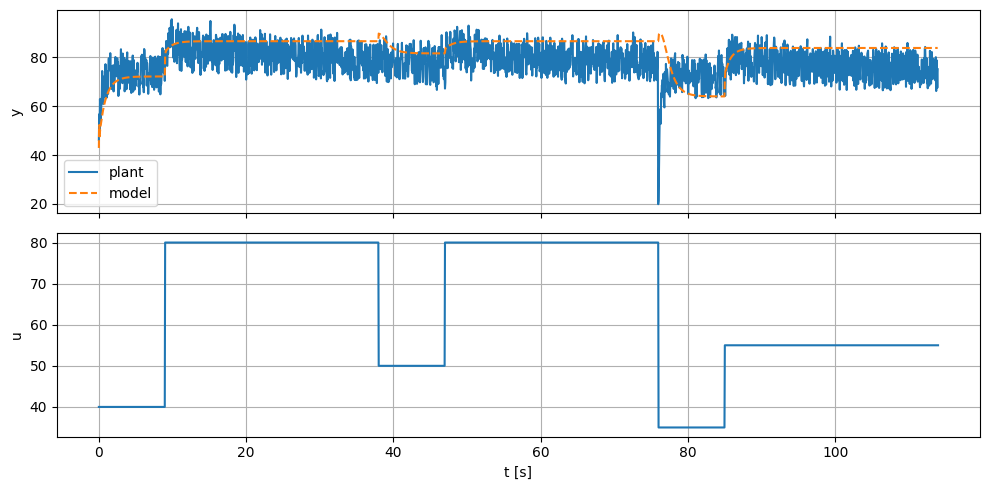

In [18]:
mae = evaluate_mae_physical(problem, test_data, scaler, y_names=y_names)
print("concatenated test MAE (physical):", mae)

from helper.koopman import rollout_predictions

true_s, pred_s = rollout_predictions(problem, test_data)
true_p = scaler.inverse_transform(true_s)
pred_p = scaler.inverse_transform(pred_s)
t = np.arange(true_p.shape[0]) * TS
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, true_p[:, 0], label="plant")
ax[0].plot(t, pred_p[:, 0], "--", label="model")
ax[0].set_ylabel("y")
ax[0].legend()
ax[0].grid(True)
u_test = scalerU.inverse_transform(test_data["U"].reshape(-1, nu).numpy())
ax[1].plot(np.arange(u_test.shape[0]) * TS, u_test[:, 0])
ax[1].set_ylabel("u")
ax[1].set_xlabel("t [s]")
ax[1].grid(True)
fig.tight_layout()
